# A题问题1：原圆柱重建—真实裁剪—碎片独立 GJK—并查集

本 Notebook 采用“重建只恢复几何，不恢复电连接”的模型：

1. 利用方向、周期共线性和边界端点，把 Excel 中同源轴段匹配为原始圆柱；
2. 在展开空间恢复长度为 5000 nm、半径为 30 nm 的完整圆柱；
3. 对每根完整圆柱重新执行周期单元裁剪与搬运，生成
   \(F_{i,k}=(C_i-k\odot P)\cap B\)；
4. 每个非空碎片都是独立导通节点。同源碎片**不自动连接，也不跳过距离计算**；
5. 最终碎片都已经位于基本区域内，碎片间只计算直接欧氏距离，不再枚举周期镜像；
6. AABB 和完整圆柱仅用于安全粗筛，候选碎片对使用真实截断支持函数 + GJK；
7. 并查集是导通主判据，BFS 只恢复一条展示路径。

截断碎片通常带有斜切面，并不是普通小圆柱。本实现不使用截断多面体或外包胶囊，
而是直接用 SLSQP 对“有限圆柱与边界盒的交集”求数值支持点。

In [1]:
from __future__ import annotations

from collections import deque
from dataclasses import dataclass, field
from itertools import combinations, product
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from scipy.optimize import minimize

np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.max_colwidth", 140)
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
try:
    get_ipython().run_line_magic("matplotlib", "inline")
    IN_NOTEBOOK = True
except NameError:
    IN_NOTEBOOK = False

# 全部长度单位均为 nm。
CYLINDER_LENGTH = 5000.0
CYLINDER_RADIUS = 30.0
CONDUCTION_THRESHOLD = 1.8
EXPORTED_MIN_AXIS_LENGTH = 500.0

# 附件反推边界。组1、组2的 y/z=±500 周期拼接可达到约 1e-11 nm 误差；
# 这与题面“三轴均为±5000”矛盾，因此必须在论文中作为附件数据假设明确说明。
BOUNDARY_PRESET = "inferred_attachment"
INFERRED_HALF_EXTENTS = {
    "组1": np.array([5000.0, 500.0, 500.0]),
    "组2": np.array([5000.0, 500.0, 500.0]),
    "组3": np.array([5000.0, 5000.0, 5000.0]),
}
STRICT_HALF_EXTENTS = np.array([5000.0, 5000.0, 5000.0])

# 无真实端点时，在附件隐含“轴长不足500不输出”的条件下，
# 用可行 alpha 区间的中点恢复；0和1可用于端点敏感性分析。
AMBIGUITY_FRACTION = 0.5

ANGLE_DEFECT_TOL = 1e-10
BOUNDARY_TOL = 1e-6
LINE_TOL = 1e-5
LENGTH_TOL = 1e-5
FRAGMENT_FEASIBILITY_TOL = 2e-7
GJK_TOL = 1e-9
GJK_MAX_ITERATIONS = 160
NUMERICAL_DECISION_TOL = 1e-5
NEAR_THRESHOLD_TOL = 1e-4


def half_extents_for_sheet(sheet_name: str) -> np.ndarray:
    if BOUNDARY_PRESET == "strict_statement":
        return STRICT_HALF_EXTENTS.copy()
    if BOUNDARY_PRESET == "inferred_attachment":
        if sheet_name not in INFERRED_HALF_EXTENTS:
            raise KeyError(f"没有为工作表 {sheet_name!r} 配置附件反推边界。")
        return INFERRED_HALF_EXTENTS[sheet_name].copy()
    raise ValueError("BOUNDARY_PRESET 必须是 'inferred_attachment' 或 'strict_statement'。")


def find_excel_file() -> Path:
    candidates = [p for p in Path.cwd().glob("*.xlsx") if not p.name.startswith("~$")]
    preferred = [p for p in candidates if "附件" in p.stem]
    if preferred:
        return preferred[0]
    if len(candidates) == 1:
        return candidates[0]
    raise FileNotFoundError("当前目录中没有找到唯一的 Excel 附件。")


EXCEL_PATH = find_excel_file()
print("读取附件：", EXCEL_PATH.resolve())
print("边界解释：", BOUNDARY_PRESET)

读取附件： E:\华数杯\2026年第七届华数杯数学建模竞赛赛题\A题 微构体中填充导电介质的仿真优化\附件.xlsx
边界解释： inferred_attachment


## 1. 读取附件并审计轴长

每一行先视为一个“已列轴片段”，而不是完整圆柱，也不是最终导通节点。身份匹配只在
重建阶段使用；导通阶段的节点将在重新裁剪后生成。

In [2]:
def load_workbook(path: Path) -> Dict[str, pd.DataFrame]:
    raw_sheets = pd.read_excel(path, sheet_name=None, header=None, engine="openpyxl")
    sheets: Dict[str, pd.DataFrame] = {}
    coordinate_names = ["x1", "y1", "z1", "x2", "y2", "z2"]

    for sheet_name, raw in raw_sheets.items():
        data = raw.iloc[2:, :6].copy()
        data.columns = coordinate_names
        data = data.dropna(how="any").astype(float).reset_index(drop=True)
        data["piece_index"] = np.arange(len(data), dtype=int)
        data["excel_row"] = np.arange(3, 3 + len(data), dtype=int)
        data["medium_label"] = [f"A{i+1}" for i in range(len(data))]
        sheets[sheet_name] = data
    return sheets


workbook = load_workbook(EXCEL_PATH)

input_summary = []
for sheet_name, df in workbook.items():
    p = df[["x1", "y1", "z1"]].to_numpy(float)
    q = df[["x2", "y2", "z2"]].to_numpy(float)
    lengths = np.linalg.norm(q - p, axis=1)
    input_summary.append({
        "分组": sheet_name,
        "附件行数": len(df),
        "轴长约为5000": int(np.isclose(lengths, CYLINDER_LENGTH, atol=LENGTH_TOL).sum()),
        "轴长小于5000": int((lengths < CYLINDER_LENGTH - LENGTH_TOL).sum()),
        "轴长小于500": int((lengths < EXPORTED_MIN_AXIS_LENGTH - LENGTH_TOL).sum()),
        "最短轴长/nm": float(lengths.min()),
        "推断半边长/nm": tuple(half_extents_for_sheet(sheet_name)),
    })
display(pd.DataFrame(input_summary))

,分组,附件行数,轴长约为5000,轴长小于5000,轴长小于500,最短轴长/nm,推断半边长/nm
0,组1,12,2,10,0,1019.117255,"(5000.0, 500.0, 500.0)"
1,组2,49,11,38,0,577.473950,"(5000.0, 500.0, 500.0)"
2,组3,535,155,380,0,525.697382,"(5000.0, 5000.0, 5000.0)"


## 2. 普通有限圆柱

普通圆柱只用于两处：恢复出的父圆柱，以及截断 GJK 前的安全下界粗筛。最终碎片不是
普通小圆柱。

In [3]:
class FiniteCylinder:
    def __init__(self, p: np.ndarray, q: np.ndarray, radius: float = CYLINDER_RADIUS):
        self.p = np.asarray(p, dtype=float)
        self.q = np.asarray(q, dtype=float)
        self.radius = float(radius)
        vector = self.q - self.p
        self.length = float(np.linalg.norm(vector))
        if self.length <= 0.0:
            raise ValueError("圆柱轴长必须大于0。")
        self.u = vector / self.length
        self.center = 0.5 * (self.p + self.q)
        self.half_length = 0.5 * self.length
        radial_extent = self.radius * np.sqrt(np.maximum(0.0, 1.0 - self.u**2))
        extent = self.half_length * np.abs(self.u) + radial_extent
        self.aabb_min = self.center - extent
        self.aabb_max = self.center + extent

    def translated(self, shift: np.ndarray) -> "FiniteCylinder":
        shift = np.asarray(shift, dtype=float)
        return FiniteCylinder(self.p + shift, self.q + shift, self.radius)

    def support(self, direction: np.ndarray) -> np.ndarray:
        d = np.asarray(direction, dtype=float)
        axial_component = float(np.dot(d, self.u))
        radial_direction = d - axial_component * self.u
        radial_norm = float(np.linalg.norm(radial_direction))
        axial_point = self.half_length * self.u if axial_component >= 0.0 else -self.half_length * self.u
        radial_point = (np.zeros(3) if radial_norm <= 1e-14
                        else self.radius * radial_direction / radial_norm)
        return self.center + axial_point + radial_point

def canonical_direction(vector: np.ndarray) -> np.ndarray:
    u = np.asarray(vector, dtype=float)
    u /= np.linalg.norm(u)
    pivot = int(np.argmax(np.abs(u)))
    if u[pivot] < 0.0:
        u = -u
    return u


@dataclass
class AxisPiece:
    piece_index: int
    excel_row: int
    label: str
    p: np.ndarray
    q: np.ndarray
    length: float
    direction: np.ndarray

    @property
    def center(self) -> np.ndarray:
        return 0.5 * (self.p + self.q)

    def oriented_endpoints(self, group_direction: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        if np.dot(self.q - self.p, group_direction) >= 0.0:
            return self.p.copy(), self.q.copy()
        return self.q.copy(), self.p.copy()


def dataframe_to_pieces(df: pd.DataFrame) -> List[AxisPiece]:
    pieces = []
    for _, row in df.iterrows():
        p = row[["x1", "y1", "z1"]].to_numpy(float)
        q = row[["x2", "y2", "z2"]].to_numpy(float)
        vector = q - p
        length = float(np.linalg.norm(vector))
        pieces.append(AxisPiece(
            piece_index=int(row["piece_index"]),
            excel_row=int(row["excel_row"]),
            label=str(row["medium_label"]),
            p=p,
            q=q,
            length=length,
            direction=canonical_direction(vector),
        ))
    return pieces


class UnionFind:
    def __init__(self, n: int):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x: int) -> int:
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, a: int, b: int) -> bool:
        root_a, root_b = self.find(a), self.find(b)
        if root_a == root_b:
            return False
        if self.rank[root_a] < self.rank[root_b]:
            root_a, root_b = root_b, root_a
        self.parent[root_b] = root_a
        if self.rank[root_a] == self.rank[root_b]:
            self.rank[root_a] += 1
        return True

    def connected(self, a: int, b: int) -> bool:
        return self.find(a) == self.find(b)

## 3. 身份匹配、周期展开与 5000 nm 父圆柱重建

两行只有同时满足“方向相同、周期平移后共线、合并跨度不超过5000”才进入同一个
身份分量。这个身份并查集随后丢弃，绝不直接用于导通。

In [4]:
def integer_shift_vectors(direction: np.ndarray, periods: np.ndarray) -> np.ndarray:
    limits = np.ceil(CYLINDER_LENGTH * np.abs(direction) / periods).astype(int) + 2
    integer_vectors = np.asarray(
        list(product(*(range(-int(k), int(k) + 1) for k in limits))),
        dtype=int,
    )
    return integer_vectors


def best_pair_alignment(
    piece_i: AxisPiece,
    piece_j: AxisPiece,
    direction: np.ndarray,
    periods: np.ndarray,
) -> Tuple[float, float, np.ndarray]:
    integers = integer_shift_vectors(direction, periods)
    shifts = integers * periods[None, :]
    deltas = piece_j.center[None, :] + shifts - piece_i.center[None, :]
    axial = deltas @ direction
    perpendicular = deltas - axial[:, None] * direction[None, :]
    residuals = np.linalg.norm(perpendicular, axis=1)
    spans = (
        np.maximum(piece_i.length / 2.0, axial + piece_j.length / 2.0)
        - np.minimum(-piece_i.length / 2.0, axial - piece_j.length / 2.0)
    )
    admissible = spans <= CYLINDER_LENGTH + LENGTH_TOL
    if not np.any(admissible):
        return math.inf, math.inf, np.zeros(3, dtype=int)
    scores = np.where(admissible, residuals, np.inf)
    index = int(np.argmin(scores))
    return float(residuals[index]), float(spans[index]), integers[index]


def group_axis_pieces(pieces: Sequence[AxisPiece], periods: np.ndarray) -> List[List[int]]:
    identity_dsu = UnionFind(len(pieces))
    for i in range(len(pieces)):
        for j in range(i + 1, len(pieces)):
            direction_defect = 1.0 - abs(float(np.dot(pieces[i].direction, pieces[j].direction)))
            if direction_defect > ANGLE_DEFECT_TOL:
                continue
            residual, span, _ = best_pair_alignment(
                pieces[i], pieces[j], pieces[i].direction, periods
            )
            if residual <= LINE_TOL and span <= CYLINDER_LENGTH + LENGTH_TOL:
                identity_dsu.union(i, j)

    components: Dict[int, List[int]] = {}
    for i in range(len(pieces)):
        components.setdefault(identity_dsu.find(i), []).append(i)
    return sorted(components.values(), key=lambda group: min(pieces[i].piece_index for i in group))


def endpoint_on_boundary(point: np.ndarray, half_extents: np.ndarray) -> bool:
    return bool(np.any(np.abs(np.abs(point) - half_extents) <= BOUNDARY_TOL))


def align_point_to_target(
    point: np.ndarray,
    target: np.ndarray,
    periods: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, float]:
    integer_shift = np.rint((target - point) / periods).astype(int)
    lifted = point + integer_shift * periods
    residual = float(np.linalg.norm(lifted - target))
    return lifted, integer_shift, residual


def unwrap_group_intervals(
    group: Sequence[int],
    pieces: Sequence[AxisPiece],
    direction: np.ndarray,
    periods: np.ndarray,
) -> Tuple[np.ndarray, List[dict], float]:
    reference = pieces[group[0]]
    ref_low, ref_high = reference.oriented_endpoints(direction)
    origin = ref_low.copy()
    intervals = []
    maximum_residual = 0.0

    for piece_index in group:
        piece = pieces[piece_index]
        low, high = piece.oriented_endpoints(direction)
        residual, _, integer_shift = best_pair_alignment(reference, piece, direction, periods)
        if residual > LINE_TOL:
            raise ValueError(f"{piece.label} 无法周期展开到父圆柱参考直线。")
        shift = integer_shift * periods
        low_lifted, high_lifted = low + shift, high + shift
        t_low = float(np.dot(low_lifted - origin, direction))
        t_high = float(np.dot(high_lifted - origin, direction))
        if t_high < t_low:
            t_low, t_high = t_high, t_low
            low, high = high, low
            low_lifted, high_lifted = high_lifted, low_lifted
        low_residual = np.linalg.norm((low_lifted - origin) - t_low * direction)
        high_residual = np.linalg.norm((high_lifted - origin) - t_high * direction)
        maximum_residual = max(maximum_residual, float(low_residual), float(high_residual))
        intervals.append({
            "piece_index": piece_index,
            "t_low": t_low,
            "t_high": t_high,
            "raw_low": low,
            "raw_high": high,
            "integer_shift": integer_shift,
        })
    return origin, intervals, maximum_residual


@dataclass
class ParentCylinder:
    parent_id: int
    cylinder: FiniteCylinder
    source_piece_indices: Tuple[int, ...]
    source_excel_rows: Tuple[int, ...]
    direction: np.ndarray
    reconstruction_status: str
    observed_length_sum: float
    ambiguity_delta: float = 0.0
    alpha_value: Optional[float] = None
    alpha_interval: Optional[Tuple[float, float]] = None
    line_residual: float = 0.0


@dataclass
class ReconstructionResult:
    sheet_name: str
    half_extents: np.ndarray
    periods: np.ndarray
    pieces: List[AxisPiece]
    parents: List[ParentCylinder]
    piece_to_parent: Dict[int, int]


def reconstruct_parent_cylinders(
    sheet_name: str,
    df: pd.DataFrame,
    ambiguity_fraction: float = AMBIGUITY_FRACTION,
) -> ReconstructionResult:
    if not 0.0 <= ambiguity_fraction <= 1.0:
        raise ValueError("ambiguity_fraction 必须位于[0,1]。")
    half_extents = half_extents_for_sheet(sheet_name)
    periods = 2.0 * half_extents
    pieces = dataframe_to_pieces(df)
    groups = group_axis_pieces(pieces, periods)
    parents: List[ParentCylinder] = []
    piece_to_parent: Dict[int, int] = {}

    for parent_id, group in enumerate(groups):
        direction = pieces[group[0]].direction.copy()
        aligned_directions = []
        anchors = []
        for piece_index in group:
            piece = pieces[piece_index]
            u = piece.direction.copy()
            if np.dot(u, direction) < 0.0:
                u = -u
            aligned_directions.append(u)
        direction = np.mean(aligned_directions, axis=0)
        direction /= np.linalg.norm(direction)
        direction = canonical_direction(direction)

        for piece_index in group:
            piece = pieces[piece_index]
            low, high = piece.oriented_endpoints(direction)
            if not endpoint_on_boundary(low, half_extents):
                anchors.append(("low", low, piece_index))
            if not endpoint_on_boundary(high, half_extents):
                anchors.append(("high", high, piece_index))

        origin, intervals, line_residual = unwrap_group_intervals(
            group, pieces, direction, periods
        )
        if line_residual > LINE_TOL:
            raise ValueError(f"{sheet_name} P{parent_id+1} 周期共线残差过大：{line_residual}")

        ambiguity_delta = 0.0
        alpha_value = None
        alpha_interval = None

        if len(anchors) == 2 and {anchors[0][0], anchors[1][0]} == {"low", "high"}:
            low_anchor = next(point for kind, point, _ in anchors if kind == "low")
            high_anchor = next(point for kind, point, _ in anchors if kind == "high")
            target_high = low_anchor + CYLINDER_LENGTH * direction
            _, _, residual = align_point_to_target(high_anchor, target_high, periods)
            if residual > LENGTH_TOL:
                raise ValueError(
                    f"{sheet_name} P{parent_id+1} 两个真实端点不能组成5000 nm圆柱，残差={residual:.6g}。"
                )
            p0 = low_anchor
            p1 = target_high
            status = "双真实端点唯一恢复"
        elif len(anchors) == 1:
            kind, anchor, _ = anchors[0]
            if kind == "low":
                p0, p1 = anchor, anchor + CYLINDER_LENGTH * direction
            else:
                p1, p0 = anchor, anchor - CYLINDER_LENGTH * direction
            status = "单真实端点唯一恢复"
        elif len(anchors) == 0:
            t_min = min(item["t_low"] for item in intervals)
            t_max = max(item["t_high"] for item in intervals)
            visible_span = t_max - t_min
            ambiguity_delta = CYLINDER_LENGTH - visible_span
            if ambiguity_delta < -LENGTH_TOL:
                raise ValueError(
                    f"{sheet_name} P{parent_id+1} 展开跨度超过5000：{visible_span:.9f}。"
                )
            ambiguity_delta = max(0.0, ambiguity_delta)
            alpha_low = max(0.0, ambiguity_delta - EXPORTED_MIN_AXIS_LENGTH)
            alpha_high = min(ambiguity_delta, EXPORTED_MIN_AXIS_LENGTH)
            if alpha_low > alpha_high + LENGTH_TOL:
                alpha_low, alpha_high = 0.0, ambiguity_delta
            alpha_value = alpha_low + ambiguity_fraction * (alpha_high - alpha_low)
            alpha_interval = (alpha_low, alpha_high)
            p0 = origin + (t_min - alpha_value) * direction
            p1 = p0 + CYLINDER_LENGTH * direction
            status = "无真实端点：连续歧义，按alpha区间取值"
        else:
            anchor_description = [(kind, pieces[index].label) for kind, _, index in anchors]
            raise ValueError(
                f"{sheet_name} P{parent_id+1} 出现无法解释的真实端点集合：{anchor_description}。"
            )

        cylinder = FiniteCylinder(p0, p1, CYLINDER_RADIUS)
        if abs(cylinder.length - CYLINDER_LENGTH) > LENGTH_TOL:
            raise AssertionError("恢复后的父圆柱长度不是5000 nm。")
        source_indices = tuple(sorted(pieces[i].piece_index for i in group))
        source_rows = tuple(sorted(pieces[i].excel_row for i in group))
        parent = ParentCylinder(
            parent_id=parent_id,
            cylinder=cylinder,
            source_piece_indices=source_indices,
            source_excel_rows=source_rows,
            direction=direction,
            reconstruction_status=status,
            observed_length_sum=float(sum(pieces[i].length for i in group)),
            ambiguity_delta=ambiguity_delta,
            alpha_value=alpha_value,
            alpha_interval=alpha_interval,
            line_residual=line_residual,
        )
        parents.append(parent)
        for piece_index in source_indices:
            piece_to_parent[piece_index] = parent_id

    return ReconstructionResult(
        sheet_name=sheet_name,
        half_extents=half_extents,
        periods=periods,
        pieces=pieces,
        parents=parents,
        piece_to_parent=piece_to_parent,
    )


reconstructions = {
    sheet_name: reconstruct_parent_cylinders(sheet_name, df)
    for sheet_name, df in workbook.items()
}

reconstruction_summary = []
for sheet_name, reconstruction in reconstructions.items():
    ambiguous = [p for p in reconstruction.parents if p.alpha_interval is not None]
    reconstruction_summary.append({
        "分组": sheet_name,
        "附件轴片段": len(reconstruction.pieces),
        "恢复父圆柱": len(reconstruction.parents),
        "唯一恢复": len(reconstruction.parents) - len(ambiguous),
        "连续歧义": len(ambiguous),
        "最大周期共线残差/nm": max(p.line_residual for p in reconstruction.parents),
    })
display(pd.DataFrame(reconstruction_summary))

ambiguity_rows = []
for sheet_name, reconstruction in reconstructions.items():
    for parent in reconstruction.parents:
        if parent.alpha_interval is not None:
            ambiguity_rows.append({
                "分组": sheet_name,
                "父圆柱": f"P{parent.parent_id+1}",
                "来源Excel行": parent.source_excel_rows,
                "缺失长度Delta/nm": parent.ambiguity_delta,
                "alpha可行区间/nm": parent.alpha_interval,
                "本次alpha/nm": parent.alpha_value,
            })
if ambiguity_rows:
    display(pd.DataFrame(ambiguity_rows))

,分组,附件轴片段,恢复父圆柱,唯一恢复,连续歧义,最大周期共线残差/nm
0,组1,12,7,6,1,1.033101e-12
1,组2,49,28,28,0,2.493347e-12
2,组3,535,354,353,1,3.273569e-11


,分组,父圆柱,来源Excel行,缺失长度Delta/nm,alpha可行区间/nm,本次alpha/nm
0,组1,P7,"(10,)",576.688471,"(76.68847053578247, 500.0)",288.344235
1,组3,P73,"(75,)",406.484515,"(0.0, 406.4845150463434)",203.242258


## 4. 真实截断碎片的支持函数

对父圆柱使用局部坐标

\[
x=c+Q\operatorname{diag}(h,r,r)y,
\]

其中 \(|y_0|\le1\)、\(y_1^2+y_2^2\le1\)，再加入盒约束
\(B_{\min}\le x\le B_{\max}\)。给定方向 \(d\)，支持点就是这个三变量凸问题中
最大化 \(d^Tx\) 的解。这里直接采用 SLSQP 原问题的数值解，并检查返回点确实满足
圆柱与盒约束；不再构造对偶问题或支持误差证书。

In [5]:
def orthobasis(axis: np.ndarray) -> np.ndarray:
    u = np.asarray(axis, dtype=float)
    u /= np.linalg.norm(u)
    helper = np.eye(3)[int(np.argmin(np.abs(u)))]
    v = np.cross(u, helper)
    v /= np.linalg.norm(v)
    w = np.cross(u, v)
    return np.column_stack((u, v, w))


def cylinder_axis_segment_in_box(
    cylinder: FiniteCylinder,
    box_min: np.ndarray,
    box_max: np.ndarray,
) -> Optional[Tuple[np.ndarray, np.ndarray]]:
    """有限圆柱轴段与盒的线裁剪；仅描述轴线，不近似圆柱体积。"""
    t_min, t_max = -cylinder.half_length, cylinder.half_length
    for axis_index in range(3):
        coefficient = float(cylinder.u[axis_index])
        if abs(coefficient) <= 1e-14:
            if not (
                box_min[axis_index] - BOUNDARY_TOL
                <= cylinder.center[axis_index]
                <= box_max[axis_index] + BOUNDARY_TOL
            ):
                return None
            continue
        t1 = (box_min[axis_index] - cylinder.center[axis_index]) / coefficient
        t2 = (box_max[axis_index] - cylinder.center[axis_index]) / coefficient
        lower, upper = min(t1, t2), max(t1, t2)
        t_min, t_max = max(t_min, lower), min(t_max, upper)
        if t_min > t_max + LENGTH_TOL:
            return None
    if t_max - t_min <= LENGTH_TOL:
        return None
    return (
        cylinder.center + t_min * cylinder.u,
        cylinder.center + t_max * cylinder.u,
    )


class ClippedCylinderFragment:
    """一个独立碎片 F=(有限圆柱)∩(轴对齐边界盒)。"""

    def __init__(
        self,
        parent_id: int,
        fragment_index_in_parent: int,
        integer_shift: np.ndarray,
        cylinder: FiniteCylinder,
        box_min: np.ndarray,
        box_max: np.ndarray,
        feasible_hint: np.ndarray,
    ):
        self.parent_id = int(parent_id)
        self.fragment_index_in_parent = int(fragment_index_in_parent)
        self.integer_shift = np.asarray(integer_shift, dtype=int)
        self.cylinder = cylinder
        self.box_min = np.asarray(box_min, dtype=float)
        self.box_max = np.asarray(box_max, dtype=float)
        self.axis = cylinder.u
        self.h = cylinder.half_length
        self.r = cylinder.radius
        self.Q = orthobasis(self.axis)
        self.M = self.Q @ np.diag([self.h, self.r, self.r])
        self.optimized_support_calls = 0
        self.support_solver_fallbacks = 0
        self._support_cache: Dict[Tuple[float, float, float], np.ndarray] = {}
        self.source_piece_index: Optional[int] = None
        self.source_label: Optional[str] = None
        self.source_excel_row: Optional[int] = None

        # A y <= b：这里只保存6个盒约束；|y0|<=1由SLSQP变量边界保证。
        scale = np.maximum(self.box_max - self.box_min, 1.0)
        upper_a = self.M / scale[:, None]
        lower_a = -self.M / scale[:, None]
        self.constraint_a = np.vstack((upper_a, lower_a))
        self.constraint_b = np.r_[
            (self.box_max - self.cylinder.center) / scale,
            (self.cylinder.center - self.box_min) / scale,
        ]

        self.is_uncut = bool(
            np.all(cylinder.aabb_min >= self.box_min - FRAGMENT_FEASIBILITY_TOL)
            and np.all(cylinder.aabb_max <= self.box_max + FRAGMENT_FEASIBILITY_TOL)
        )
        if self.is_uncut:
            projected = cylinder.center.copy()
        else:
            projected = self.project_intersection(feasible_hint, max_iterations=10000)
        self.feasible_y = np.linalg.solve(self.M, projected - self.cylinder.center)
        violation = self.violation_nm(self.feasible_y)
        if violation > FRAGMENT_FEASIBILITY_TOL:
            # Dykstra 对极薄侧切片可能收敛较慢；用显式凸可行性问题复核，
            # 避免把真实薄片误删为空交。
            constraints = [
                {
                    "type": "ineq",
                    "fun": lambda y: self.constraint_b - self.constraint_a @ y,
                    "jac": lambda y: -self.constraint_a,
                },
                {
                    "type": "ineq",
                    "fun": lambda y: 1.0 - y[1] ** 2 - y[2] ** 2,
                    "jac": lambda y: np.array([0.0, -2.0 * y[1], -2.0 * y[2]]),
                },
            ]
            start_y = np.clip(self.feasible_y, -1.0, 1.0)
            feasibility = minimize(
                lambda y: 0.5 * float(np.dot(y - start_y, y - start_y)),
                start_y,
                jac=lambda y: y - start_y,
                method="SLSQP",
                bounds=[(-1.0, 1.0)] * 3,
                constraints=constraints,
                options={"ftol": 1e-13, "maxiter": 1000},
            )
            if self.violation_nm(feasibility.x) <= FRAGMENT_FEASIBILITY_TOL:
                self.feasible_y = feasibility.x.copy()
                violation = self.violation_nm(self.feasible_y)
        if violation > FRAGMENT_FEASIBILITY_TOL:
            raise ValueError(f"圆柱与盒没有可确认的非空交集，残差={violation:.6g} nm。")

        # 这是 F 的安全外包盒，不一定是最紧盒；只用于粗筛，不能直接判断电极接触。
        self.aabb_min = np.maximum(cylinder.aabb_min, self.box_min)
        self.aabb_max = np.minimum(cylinder.aabb_max, self.box_max)
        if np.any(self.aabb_min > self.aabb_max + FRAGMENT_FEASIBILITY_TOL):
            raise ValueError("AABB 不相交。")
        self.center = 0.5 * (self.aabb_min + self.aabb_max)

    def project_cylinder(self, point: np.ndarray) -> np.ndarray:
        delta = np.asarray(point, dtype=float) - self.cylinder.center
        axial = float(np.dot(delta, self.axis))
        radial = delta - axial * self.axis
        radial_norm = float(np.linalg.norm(radial))
        if radial_norm > self.r:
            radial *= self.r / radial_norm
        return (
            self.cylinder.center
            + np.clip(axial, -self.h, self.h) * self.axis
            + radial
        )

    def project_intersection(
        self,
        target: np.ndarray,
        max_iterations: int = 3000,
        tolerance: float = 2e-11,
    ) -> np.ndarray:
        """Dykstra 投影；若交集非空则收敛到 F 内的点。"""
        x = np.asarray(target, dtype=float).copy()
        correction_cylinder = np.zeros(3)
        correction_box = np.zeros(3)
        for _ in range(max_iterations):
            y_cylinder = self.project_cylinder(x + correction_cylinder)
            correction_cylinder = x + correction_cylinder - y_cylinder
            new_x = np.clip(y_cylinder + correction_box, self.box_min, self.box_max)
            correction_box = y_cylinder + correction_box - new_x
            x = new_x
            if np.linalg.norm(x - self.project_cylinder(x)) <= tolerance:
                return x
        return x

    def violation_nm(self, y: np.ndarray) -> float:
        y = np.asarray(y, dtype=float)
        x = self.cylinder.center + self.M @ y
        axial_excess = max(0.0, abs(float(y[0])) - 1.0) * self.h
        radial_excess = max(0.0, float(np.linalg.norm(y[1:])) - 1.0) * self.r
        box_excess = max(
            0.0,
            float(np.max(self.box_min - x)),
            float(np.max(x - self.box_max)),
        )
        return max(axial_excess, radial_excess, box_excess)

    def _primal_support(self, normalized_p: np.ndarray, start_y: np.ndarray):
        constraints = [
            {
                "type": "ineq",
                "fun": lambda y: self.constraint_b - self.constraint_a @ y,
                "jac": lambda y: -self.constraint_a,
            },
            {
                "type": "ineq",
                "fun": lambda y: 1.0 - y[1] ** 2 - y[2] ** 2,
                "jac": lambda y: np.array([0.0, -2.0 * y[1], -2.0 * y[2]]),
            },
        ]
        return minimize(
            lambda y: -float(np.dot(normalized_p, y)),
            np.asarray(start_y, dtype=float),
            jac=lambda y: -normalized_p,
            method="SLSQP",
            bounds=[(-1.0, 1.0)] * 3,
            constraints=constraints,
            options={"ftol": 1e-10, "maxiter": 500},
        )

    def support(self, direction: np.ndarray) -> np.ndarray:
        direction = np.asarray(direction, dtype=float)
        direction_norm = float(np.linalg.norm(direction))
        if direction_norm <= 1e-15:
            return self.cylinder.center + self.M @ self.feasible_y
        unit_direction = direction / direction_norm
        cache_key = tuple(np.round(unit_direction, 12))
        if cache_key in self._support_cache:
            return self._support_cache[cache_key].copy()

        # 若未裁剪圆柱的解析支持点仍在盒内，它就是交集的精确支持点。
        analytic = self.cylinder.support(unit_direction)
        if self.is_uncut or (
            np.all(analytic >= self.box_min - 1e-10)
            and np.all(analytic <= self.box_max + 1e-10)
        ):
            self._support_cache[cache_key] = analytic.copy()
            return analytic

        p = self.M.T @ unit_direction
        normalized_p = p / max(float(np.linalg.norm(p)), 1.0)

        # 从未裁剪支持点向交集投影，得到原问题的可行初值。
        start = np.zeros(3)
        start[0] = 1.0 if normalized_p[0] >= 0.0 else -1.0
        radial_norm = float(np.linalg.norm(normalized_p[1:]))
        if radial_norm > 0.0:
            start[1:] = normalized_p[1:] / radial_norm
        projected_start = self.project_intersection(self.cylinder.center + self.M @ start)
        start_y = np.linalg.solve(self.M, projected_start - self.cylinder.center)

        primal_candidates = [self._primal_support(normalized_p, start_y)]
        if not primal_candidates[0].success:
            primal_candidates.append(self._primal_support(normalized_p, self.feasible_y))

        feasible_candidates = []
        for primal in primal_candidates:
            projected = self.project_intersection(self.cylinder.center + self.M @ primal.x)
            y = np.linalg.solve(self.M, projected - self.cylinder.center)
            if self.violation_nm(y) <= FRAGMENT_FEASIBILITY_TOL:
                feasible_candidates.append((float(np.dot(normalized_p, y)), y, primal))
        if not feasible_candidates:
            messages = "; ".join(str(item.message) for item in primal_candidates)
            raise RuntimeError(f"截断碎片支持点原问题没有得到可行数值解：{messages}")
        _, y, chosen_primal = max(feasible_candidates, key=lambda item: item[0])
        if not chosen_primal.success:
            self.support_solver_fallbacks += 1
        point = self.cylinder.center + self.M @ y
        self.optimized_support_calls += 1
        self._support_cache[cache_key] = point.copy()
        return point

    def clear_support_cache(self):
        self._support_cache.clear()

    def axis_visible_segment(self) -> Optional[Tuple[np.ndarray, np.ndarray]]:
        """返回该周期单元内可见的轴线段；纯侧切碎片返回 None。"""
        return cylinder_axis_segment_in_box(self.cylinder, self.box_min, self.box_max)

    @property
    def display_label(self) -> str:
        if self.source_label is not None:
            return f"{self.source_label}/P{self.parent_id+1}"
        if self.axis_visible_segment() is None:
            kind = "侧切"
        else:
            kind = "补片"
        return f"P{self.parent_id+1}-{kind}{self.fragment_index_in_parent+1}"


def fragment_shift_ranges(cylinder: FiniteCylinder, half_extents: np.ndarray) -> List[range]:
    periods = 2.0 * half_extents
    lower = np.ceil(
        (cylinder.aabb_min - half_extents) / periods - 1e-12
    ).astype(int)
    upper = np.floor(
        (cylinder.aabb_max + half_extents) / periods + 1e-12
    ).astype(int)
    return [range(int(lower[j]), int(upper[j]) + 1) for j in range(3)]


def endpoint_match_error(
    segment: Tuple[np.ndarray, np.ndarray],
    piece: AxisPiece,
) -> float:
    a, b = segment
    direct = max(float(np.linalg.norm(a - piece.p)), float(np.linalg.norm(b - piece.q)))
    reverse = max(float(np.linalg.norm(a - piece.q)), float(np.linalg.norm(b - piece.p)))
    return min(direct, reverse)


@dataclass
class FragmentGenerationResult:
    fragments: List[ClippedCylinderFragment]
    aabb_cell_candidates: int
    rejected_empty_candidates: int
    axis_fragments: int
    long_axis_fragments: int
    recovered_short_axis_fragments: int
    side_only_fragments: int
    matched_source_rows: int
    maximum_source_match_error: float


def generate_fragments(reconstruction: ReconstructionResult) -> FragmentGenerationResult:
    half_extents = reconstruction.half_extents
    periods = reconstruction.periods
    box_min, box_max = -half_extents, half_extents
    fragments: List[ClippedCylinderFragment] = []
    candidate_count = 0
    rejected_count = 0

    pieces_by_index = {piece.piece_index: piece for piece in reconstruction.pieces}

    for parent in reconstruction.parents:
        parent_fragments = []
        for integer_tuple in product(*fragment_shift_ranges(parent.cylinder, half_extents)):
            integer_shift = np.asarray(integer_tuple, dtype=int)
            candidate_count += 1
            shifted_cylinder = parent.cylinder.translated(-integer_shift * periods)
            outer_min = np.maximum(shifted_cylinder.aabb_min, box_min)
            outer_max = np.minimum(shifted_cylinder.aabb_max, box_max)
            if np.any(outer_min > outer_max + FRAGMENT_FEASIBILITY_TOL):
                rejected_count += 1
                continue
            axis_segment = cylinder_axis_segment_in_box(shifted_cylinder, box_min, box_max)
            feasible_hint = (
                0.5 * (axis_segment[0] + axis_segment[1])
                if axis_segment is not None
                else np.clip(shifted_cylinder.center, box_min, box_max)
            )
            try:
                fragment = ClippedCylinderFragment(
                    parent_id=parent.parent_id,
                    fragment_index_in_parent=len(parent_fragments),
                    integer_shift=integer_shift,
                    cylinder=shifted_cylinder,
                    box_min=box_min,
                    box_max=box_max,
                    feasible_hint=feasible_hint,
                )
            except ValueError:
                rejected_count += 1
                continue
            parent_fragments.append(fragment)

        # 仅按(parent_id,k)保留；不同k即使搬回后重合，也仍是独立物体。
        parent_fragments.sort(key=lambda item: tuple(item.integer_shift))
        for local_index, fragment in enumerate(parent_fragments):
            fragment.fragment_index_in_parent = local_index
            segment = fragment.axis_visible_segment()
            if segment is not None:
                candidates = []
                for source_index in parent.source_piece_indices:
                    piece = pieces_by_index[source_index]
                    candidates.append((endpoint_match_error(segment, piece), piece))
                error, matched_piece = min(candidates, key=lambda item: item[0])
                if error <= LINE_TOL:
                    fragment.source_piece_index = matched_piece.piece_index
                    fragment.source_label = matched_piece.label
                    fragment.source_excel_row = matched_piece.excel_row
            fragments.append(fragment)

    axis_fragments = 0
    long_axis_fragments = 0
    short_axis_fragments = 0
    side_only_fragments = 0
    matched_source_rows = set()
    match_errors = []
    for fragment in fragments:
        segment = fragment.axis_visible_segment()
        if segment is None:
            side_only_fragments += 1
            continue
        axis_fragments += 1
        axis_length = float(np.linalg.norm(segment[1] - segment[0]))
        if axis_length >= EXPORTED_MIN_AXIS_LENGTH - LENGTH_TOL:
            long_axis_fragments += 1
        else:
            short_axis_fragments += 1
        if fragment.source_piece_index is not None:
            matched_source_rows.add(fragment.source_piece_index)
            piece = pieces_by_index[fragment.source_piece_index]
            match_errors.append(endpoint_match_error(segment, piece))

    return FragmentGenerationResult(
        fragments=fragments,
        aabb_cell_candidates=candidate_count,
        rejected_empty_candidates=rejected_count,
        axis_fragments=axis_fragments,
        long_axis_fragments=long_axis_fragments,
        recovered_short_axis_fragments=short_axis_fragments,
        side_only_fragments=side_only_fragments,
        matched_source_rows=len(matched_source_rows),
        maximum_source_match_error=max(match_errors, default=0.0),
    )


fragment_generations = {
    sheet_name: generate_fragments(reconstruction)
    for sheet_name, reconstruction in reconstructions.items()
}

fragment_summary = []
for sheet_name, generation in fragment_generations.items():
    fragment_summary.append({
        "分组": sheet_name,
        "AABB周期单元候选": generation.aabb_cell_candidates,
        "排除空交候选": generation.rejected_empty_candidates,
        "最终独立碎片": len(generation.fragments),
        "轴长>=500的碎片": generation.long_axis_fragments,
        "恢复的短轴碎片": generation.recovered_short_axis_fragments,
        "纯侧切碎片": generation.side_only_fragments,
        "匹配回附件行": generation.matched_source_rows,
        "最大端点匹配误差/nm": generation.maximum_source_match_error,
    })
fragment_audit = pd.DataFrame(fragment_summary)
display(fragment_audit)

for sheet_name, generation in fragment_generations.items():
    if generation.long_axis_fragments != len(workbook[sheet_name]):
        warnings.warn(
            f"{sheet_name}: 重裁剪后轴长>=500的碎片数 {generation.long_axis_fragments} "
            f"与附件行数 {len(workbook[sheet_name])} 不一致。"
        )
    if generation.matched_source_rows != len(workbook[sheet_name]):
        warnings.warn(
            f"{sheet_name}: 只有 {generation.matched_source_rows}/{len(workbook[sheet_name])} "
            "行被重裁剪结果逐端点匹配。"
        )

,分组,AABB周期单元候选,排除空交候选,最终独立碎片,轴长>=500的碎片,恢复的短轴碎片,纯侧切碎片,匹配回附件行,最大端点匹配误差/nm
0,组1,20,4,16,12,3,1,12,8.754625e-12
1,组2,68,11,57,49,4,4,49,1.797340e-11
2,组3,637,43,594,535,54,5,535,4.465099e-11


## 5. 数值支持点 GJK

截断支持点由 SLSQP 数值求得，GJK 据此迭代距离上下界。若迭代区间跨越 1.8 nm，
程序会增加迭代重算；仍未收敛则报错，不会静默当作“不导通”。由于不再计算对偶证书，
这里的下界属于高精度数值结果，而不是带严格误差证明的下界。

In [6]:
@dataclass
class SupportPoint:
    w: np.ndarray
    point_a: np.ndarray
    point_b: np.ndarray


@dataclass
class GJKResult:
    lower_bound: float
    upper_bound: float
    point_a: np.ndarray
    point_b: np.ndarray
    iterations: int
    status: str

    @property
    def distance(self) -> float:
        return self.upper_bound


def closest_point_on_simplex(simplex: Sequence[SupportPoint]):
    """枚举所有至多4点的面，求原点到单纯形凸包的最近点。"""
    points = np.asarray([item.w for item in simplex])
    best = None
    for size in range(1, min(4, len(simplex)) + 1):
        for index_tuple in combinations(range(len(simplex)), size):
            indices = np.asarray(index_tuple, dtype=int)
            face = points[indices]
            gram = face @ face.T
            kkt = np.block([
                [gram, np.ones((size, 1))],
                [np.ones((1, size)), np.zeros((1, 1))],
            ])
            rhs = np.r_[np.zeros(size), 1.0]
            lambdas = np.linalg.lstsq(kkt, rhs, rcond=None)[0][:size]
            if np.min(lambdas) < -1e-9:
                continue
            lambdas = np.maximum(lambdas, 0.0)
            lambdas /= lambdas.sum()
            closest = lambdas @ face
            value = float(np.dot(closest, closest))
            if best is None or value < best[0]:
                best = value, indices, lambdas, closest
    if best is None:
        raise RuntimeError("无法求得 GJK 单纯形的最近点。")
    _, indices, lambdas, closest = best
    point_a = sum(lambdas[k] * simplex[index].point_a for k, index in enumerate(indices))
    point_b = sum(lambdas[k] * simplex[index].point_b for k, index in enumerate(indices))
    return closest, indices, point_a, point_b


def gjk_distance(
    shape_a,
    shape_b,
    threshold: Optional[float] = None,
    max_iterations: int = GJK_MAX_ITERATIONS,
    tolerance: float = GJK_TOL,
    allow_lower_separation: bool = True,
) -> GJKResult:
    def minkowski_support(direction: np.ndarray) -> SupportPoint:
        point_a = shape_a.support(direction)
        point_b = shape_b.support(-np.asarray(direction, dtype=float))
        return SupportPoint(
            w=point_a - point_b,
            point_a=point_a,
            point_b=point_b,
        )

    direction = np.asarray(shape_b.center - shape_a.center, dtype=float)
    if np.linalg.norm(direction) <= 1e-14:
        direction = np.array([1.0, 0.0, 0.0])

    simplex = [minkowski_support(direction)]
    point_a = simplex[0].point_a
    point_b = simplex[0].point_b
    lower_bound = 0.0

    for iteration in range(1, max_iterations + 1):
        closest, active, point_a, point_b = closest_point_on_simplex(simplex)
        simplex = [simplex[index] for index in active]
        upper_bound = float(np.linalg.norm(closest))
        if upper_bound <= 1e-11:
            return GJKResult(0.0, 0.0, point_a, point_b, iteration, "intersect")
        if threshold is not None and upper_bound <= threshold + NUMERICAL_DECISION_TOL:
            return GJKResult(
                lower_bound, upper_bound, point_a, point_b,
                iteration, "threshold_connected"
            )

        new_point = minkowski_support(-closest)
        raw_lower = float(np.dot(closest, new_point.w) / upper_bound)
        numerical_lower = max(0.0, raw_lower)
        lower_bound = max(lower_bound, numerical_lower)
        if (
            threshold is not None
            and allow_lower_separation
            and lower_bound > threshold + NUMERICAL_DECISION_TOL
        ):
            return GJKResult(
                lower_bound, upper_bound, point_a, point_b,
                iteration, "threshold_separated"
            )

        duplicate = any(np.linalg.norm(new_point.w - old.w) <= 1e-10 for old in simplex)
        if upper_bound - lower_bound <= tolerance * max(1.0, upper_bound) or duplicate:
            return GJKResult(
                lower_bound, upper_bound, point_a, point_b,
                iteration, "converged" if not duplicate else "duplicate"
            )
        simplex.append(new_point)

    return GJKResult(
        lower_bound,
        float(np.linalg.norm(point_a - point_b)),
        point_a,
        point_b,
        max_iterations,
        "max_iterations",
    )


def classify_gjk(
    result: GJKResult,
    threshold: float,
    allow_lower_separation: bool,
) -> str:
    if result.upper_bound <= threshold + NUMERICAL_DECISION_TOL:
        return "connected"
    if (
        allow_lower_separation
        and result.lower_bound > threshold + NUMERICAL_DECISION_TOL
    ):
        return "separated"
    if result.status in {"converged", "duplicate"}:
        return "separated"
    return "uncertain"


def clear_shape_support_cache(shape):
    if hasattr(shape, "clear_support_cache"):
        shape.clear_support_cache()


def gjk_decision(
    shape_a,
    shape_b,
    threshold: float,
    allow_lower_separation: bool,
) -> Tuple[str, GJKResult]:
    result = gjk_distance(
        shape_a,
        shape_b,
        threshold=threshold,
        allow_lower_separation=allow_lower_separation,
    )
    decision = classify_gjk(result, threshold, allow_lower_separation)
    near_threshold = abs(result.upper_bound - threshold) <= NEAR_THRESHOLD_TOL
    if decision != "uncertain" and not near_threshold:
        return decision, result

    clear_shape_support_cache(shape_a)
    clear_shape_support_cache(shape_b)
    retry = gjk_distance(
        shape_a,
        shape_b,
        threshold=threshold,
        max_iterations=512,
        tolerance=1e-11,
        allow_lower_separation=allow_lower_separation,
    )
    retry_decision = classify_gjk(retry, threshold, allow_lower_separation)
    if abs(retry.upper_bound - threshold) <= NEAR_THRESHOLD_TOL:
        warnings.warn(
            f"存在接近1.8 nm阈值的数值距离：{retry.upper_bound:.9f} nm。"
        )
    return retry_decision, retry


def aabb_distance(shape_a, shape_b) -> float:
    gap = np.maximum(
        0.0,
        np.maximum(shape_a.aabb_min - shape_b.aabb_max,
                   shape_b.aabb_min - shape_a.aabb_max),
    )
    return float(np.linalg.norm(gap))


def electrode_contact(
    fragment: ClippedCylinderFragment,
    half_x: float,
    side: str,
    threshold: float,
) -> Tuple[bool, float, np.ndarray]:
    if side == "left":
        point = fragment.support(np.array([-1.0, 0.0, 0.0]))
        distance = max(0.0, float(point[0] + half_x))
    elif side == "right":
        point = fragment.support(np.array([1.0, 0.0, 0.0]))
        distance = max(0.0, float(half_x - point[0]))
    else:
        raise ValueError("side 必须是 'left' 或 'right'。")
    return distance <= threshold + NUMERICAL_DECISION_TOL, distance, point

### 几何回归测试

最关键的测试是：一根圆柱越过右边界后生成左右两个碎片；两个碎片分别接触一侧电极，
但因为它们是独立节点，单根父圆柱不能让电极导通。

In [7]:
def run_geometry_tests() -> pd.DataFrame:
    # 普通圆柱解析GJK。
    a = FiniteCylinder(np.array([-50.0, 0.0, 0.0]), np.array([50.0, 0.0, 0.0]))
    b = FiniteCylinder(np.array([-50.0, 100.0, 0.0]), np.array([50.0, 100.0, 0.0]))
    parallel = gjk_distance(a, b).distance
    assert abs(parallel - 40.0) < 1e-5

    c = FiniteCylinder(np.array([60.0, 0.0, 0.0]), np.array([160.0, 0.0, 0.0]))
    coaxial = gjk_distance(a, c).distance
    assert abs(coaxial - 10.0) < 1e-5

    # 小盒中的边界穿越圆柱。
    box_min = np.array([-5.0, -5.0, -5.0])
    box_max = -box_min
    original = FiniteCylinder(np.array([4.0, 0.0, 0.0]), np.array([6.0, 0.0, 0.0]), radius=0.2)
    right_piece = ClippedCylinderFragment(
        0, 0, np.array([0, 0, 0]), original,
        box_min, box_max, np.array([4.5, 0.0, 0.0])
    )
    moved = original.translated(np.array([-10.0, 0.0, 0.0]))
    left_piece = ClippedCylinderFragment(
        0, 1, np.array([1, 0, 0]), moved,
        box_min, box_max, np.array([-4.5, 0.0, 0.0])
    )
    direct_gap = gjk_distance(left_piece, right_piece).distance
    assert direct_gap > 7.9
    left_touch, *_ = electrode_contact(left_piece, 5.0, "left", 1e-7)
    right_touch, *_ = electrode_contact(right_piece, 5.0, "right", 1e-7)
    assert left_touch and right_touch

    test_dsu = UnionFind(4)
    left_node, right_node = 2, 3
    test_dsu.union(left_node, 0)
    test_dsu.union(1, right_node)
    assert not test_dsu.connected(left_node, right_node)

    # 轴线在盒外但半径进入盒内：应生成纯侧切碎片。
    side_cylinder = FiniteCylinder(
        np.array([5.1, -1.0, 0.0]),
        np.array([5.1, 1.0, 0.0]),
        radius=0.2,
    )
    side_fragment = ClippedCylinderFragment(
        1, 0, np.zeros(3, dtype=int), side_cylinder,
        box_min, box_max, np.array([5.0, 0.0, 0.0])
    )
    assert side_fragment.axis_visible_segment() is None
    support_point = side_fragment.support(np.array([-0.4, 0.2, 0.7]))
    assert np.all(support_point >= box_min - FRAGMENT_FEASIBILITY_TOL)
    assert np.all(support_point <= box_max + FRAGMENT_FEASIBILITY_TOL)
    support_y = np.linalg.solve(
        side_fragment.M,
        support_point - side_fragment.cylinder.center,
    )
    support_violation = side_fragment.violation_nm(support_y)
    assert support_violation <= FRAGMENT_FEASIBILITY_TOL

    return pd.DataFrame({
        "测试": ["平行圆柱", "同轴端盖", "同源左右碎片直接距离", "侧切支持点约束残差"],
        "结果/nm": [parallel, coaxial, direct_gap, support_violation],
    })


display(run_geometry_tests())

,测试,结果/nm
0,平行圆柱,4.000000e+01
1,同轴端盖,1.000000e+01
2,同源左右碎片直接距离,8.000000e+00
3,侧切支持点约束残差,1.558309e-12


## 6. 碎片独立导通图：并查集主判定，BFS 展示路径

筛选顺序为：安全外包 AABB → 未裁剪完整圆柱解析 GJK 下界 → 截断碎片 GJK。
完整圆柱包含碎片，所以若完整圆柱距离已经大于1.8 nm，碎片一定不可能连接。

In [8]:
def add_edge(adjacency: List[set], a: int, b: int):
    adjacency[a].add(b)
    adjacency[b].add(a)


def bfs_path(adjacency: Sequence[set], source: int, target: int) -> Optional[List[int]]:
    previous = {source: None}
    queue = deque([source])
    while queue:
        node = queue.popleft()
        if node == target:
            break
        for neighbor in sorted(adjacency[node]):
            if neighbor not in previous:
                previous[neighbor] = node
                queue.append(neighbor)
    if target not in previous:
        return None
    path = []
    node: Optional[int] = target
    while node is not None:
        path.append(node)
        node = previous[node]
    return path[::-1]


def edge_key(a: int, b: int) -> Tuple[int, int]:
    return (a, b) if a < b else (b, a)


@dataclass
class SheetResult:
    sheet_name: str
    data: pd.DataFrame
    reconstruction: ReconstructionResult
    generation: FragmentGenerationResult
    fragments: List[ClippedCylinderFragment]
    conductive: bool
    path: Optional[List[int]]
    adjacency: List[set]
    edge_info: Dict[Tuple[int, int], dict]
    left_node: int
    right_node: int
    aabb_candidate_pairs: int
    full_cylinder_rejections: int
    clipped_gjk_calls: int
    gjk_uncertain: int


def solve_sheet(
    sheet_name: str,
    df: pd.DataFrame,
    threshold: float = CONDUCTION_THRESHOLD,
    ambiguity_fraction: float = AMBIGUITY_FRACTION,
    precomputed_reconstruction: Optional[ReconstructionResult] = None,
    precomputed_generation: Optional[FragmentGenerationResult] = None,
) -> SheetResult:
    reconstruction = (
        precomputed_reconstruction
        if precomputed_reconstruction is not None
        else reconstruct_parent_cylinders(sheet_name, df, ambiguity_fraction)
    )
    generation = (
        precomputed_generation
        if precomputed_generation is not None
        else generate_fragments(reconstruction)
    )
    fragments = generation.fragments
    n = len(fragments)
    left_node, right_node = n, n + 1
    dsu = UnionFind(n + 2)
    adjacency = [set() for _ in range(n + 2)]
    edge_info: Dict[Tuple[int, int], dict] = {}
    half_x = float(reconstruction.half_extents[0])

    # 电极只与真实碎片直接判断，不使用松AABB，也不使用周期镜像。
    for index, fragment in enumerate(fragments):
        left_connected, left_distance, left_point = electrode_contact(
            fragment, half_x, "left", threshold
        )
        right_connected, right_distance, right_point = electrode_contact(
            fragment, half_x, "right", threshold
        )
        if left_connected:
            dsu.union(left_node, index)
            add_edge(adjacency, left_node, index)
            edge_info[edge_key(left_node, index)] = {
                "type": "左电极",
                "distance": left_distance,
                "point": left_point,
            }
        if right_connected:
            dsu.union(right_node, index)
            add_edge(adjacency, right_node, index)
            edge_info[edge_key(right_node, index)] = {
                "type": "右电极",
                "distance": right_distance,
                "point": right_point,
            }

    aabb_candidate_pairs = 0
    full_cylinder_rejections = 0
    clipped_gjk_calls = 0
    gjk_uncertain = 0

    for i in range(n):
        for j in range(i + 1, n):
            if aabb_distance(fragments[i], fragments[j]) > threshold + 1e-12:
                continue
            aabb_candidate_pairs += 1

            # 碎片是各自未裁剪圆柱的子集；父形状距离>阈值时可安全排除。
            coarse_decision, coarse_gjk = gjk_decision(
                fragments[i].cylinder,
                fragments[j].cylinder,
                threshold,
                allow_lower_separation=True,
            )
            if coarse_decision == "separated":
                full_cylinder_rejections += 1
                continue

            decision, gjk = gjk_decision(
                fragments[i],
                fragments[j],
                threshold,
                allow_lower_separation=False,
            )
            clipped_gjk_calls += 1
            if decision == "uncertain":
                gjk_uncertain += 1
                raise RuntimeError(
                    f"{sheet_name}: 碎片{i+1}-{j+1}的GJK区间 "
                    f"[{gjk.lower_bound:.12g}, {gjk.upper_bound:.12g}] nm跨过阈值。"
                )
            if decision == "connected":
                # 注意：即使同源也必须由这里的 direct GJK 正常连接；绝不按parent_id自动合并。
                dsu.union(i, j)
                add_edge(adjacency, i, j)
                edge_info[edge_key(i, j)] = {
                    "type": "碎片-碎片",
                    "distance": gjk.upper_bound,
                    "lower_bound": gjk.lower_bound,
                    "point_i": gjk.point_a,
                    "point_j": gjk.point_b,
                    "same_parent": fragments[i].parent_id == fragments[j].parent_id,
                    "gjk_iterations": gjk.iterations,
                    "gjk_status": gjk.status,
                }

    conductive = dsu.connected(left_node, right_node)
    path = bfs_path(adjacency, left_node, right_node)
    assert conductive == (path is not None), "并查集与BFS结果不一致。"

    return SheetResult(
        sheet_name=sheet_name,
        data=df,
        reconstruction=reconstruction,
        generation=generation,
        fragments=fragments,
        conductive=conductive,
        path=path,
        adjacency=adjacency,
        edge_info=edge_info,
        left_node=left_node,
        right_node=right_node,
        aabb_candidate_pairs=aabb_candidate_pairs,
        full_cylinder_rejections=full_cylinder_rejections,
        clipped_gjk_calls=clipped_gjk_calls,
        gjk_uncertain=gjk_uncertain,
    )


def node_label(result: SheetResult, node: int) -> str:
    if node == result.left_node:
        return "L(左电极)"
    if node == result.right_node:
        return "R(右电极)"
    fragment = result.fragments[node]
    suffix = (
        f"，Excel第{fragment.source_excel_row}行"
        if fragment.source_excel_row is not None else "，重建新增"
    )
    return f"{fragment.display_label}{suffix}"


def path_table(result: SheetResult) -> pd.DataFrame:
    if result.path is None:
        return pd.DataFrame()
    rows = []
    for order, (a, b) in enumerate(zip(result.path[:-1], result.path[1:]), start=1):
        info = result.edge_info[edge_key(a, b)]
        rows.append({
            "序号": order,
            "从": node_label(result, a),
            "到": node_label(result, b),
            "连接类型": info["type"],
            "GJK数值距离/nm": info["distance"],
            "同源碎片": info.get("same_parent", False),
        })
    return pd.DataFrame(rows)

## 7. 计算三组微构体

In [9]:
results: Dict[str, SheetResult] = {}
for sheet_name, df in workbook.items():
    print(f"正在计算 {sheet_name}：{len(fragment_generations[sheet_name].fragments)} 个独立碎片 ...")
    results[sheet_name] = solve_sheet(
        sheet_name,
        df,
        precomputed_reconstruction=reconstructions[sheet_name],
        precomputed_generation=fragment_generations[sheet_name],
    )

summary = []
for sheet_name, result in results.items():
    optimized_calls = sum(fragment.optimized_support_calls for fragment in result.fragments)
    solver_fallbacks = sum(fragment.support_solver_fallbacks for fragment in result.fragments)
    path_text = (
        "无" if result.path is None
        else " → ".join(node_label(result, node) for node in result.path)
    )
    summary.append({
        "分组": sheet_name,
        "父圆柱数": len(result.reconstruction.parents),
        "独立碎片数": len(result.fragments),
        "AABB候选对": result.aabb_candidate_pairs,
        "完整圆柱GJK粗筛排除": result.full_cylinder_rejections,
        "截断GJK调用": result.clipped_gjk_calls,
        "约束支持调用": optimized_calls,
        "SLSQP可行回退": solver_fallbacks,
        "GJK数值未收敛": result.gjk_uncertain,
        "并查集判定": "导通" if result.conductive else "不导通",
        "BFS展示路径": path_text,
    })

result_summary = pd.DataFrame(summary)
display(result_summary)

for sheet_name, result in results.items():
    print(f"\n{sheet_name}：{'导通' if result.conductive else '不导通'}")
    if result.path is not None:
        display(path_table(result))

正在计算 组1：16 个独立碎片 ...


正在计算 组2：57 个独立碎片 ...


正在计算 组3：594 个独立碎片 ...


,分组,父圆柱数,独立碎片数,AABB候选对,完整圆柱GJK粗筛排除,截断GJK调用,约束支持调用,SLSQP可行回退,GJK数值未收敛,并查集判定,BFS展示路径
0,组1,7,16,16,13,3,68,0,0,不导通,无
1,组2,28,57,250,215,35,324,0,0,导通,L(左电极) → A2/P2，Excel第4行 → A12/P12，Excel第14行 → A24/P21，Excel第26行 → A39/P10，Excel第41行 → R(右电极)
2,组3,354,594,6339,6131,208,1385,2,0,导通,L(左电极) → A63/P63，Excel第65行 → A264/P222，Excel第266行 → A216/P190，Excel第218行 → A351/P295，Excel第353行 → R(右电极)



组1：不导通

组2：导通


,序号,从,到,连接类型,GJK数值距离/nm,同源碎片
0,1,L(左电极),A2/P2，Excel第4行,左电极,0.000000e+00,False
1,2,A2/P2，Excel第4行,A12/P12，Excel第14行,碎片-碎片,8.732214e-11,False
2,3,A12/P12，Excel第14行,A24/P21，Excel第26行,碎片-碎片,5.641789e-01,False
3,4,A24/P21，Excel第26行,A39/P10，Excel第41行,碎片-碎片,0.000000e+00,False
4,5,A39/P10，Excel第41行,R(右电极),右电极,0.000000e+00,False



组3：导通


,序号,从,到,连接类型,GJK数值距离/nm,同源碎片
0,1,L(左电极),A63/P63，Excel第65行,左电极,0.000000e+00,False
1,2,A63/P63，Excel第65行,A264/P222，Excel第266行,碎片-碎片,7.207331e-01,False
2,3,A264/P222，Excel第266行,A216/P190，Excel第218行,碎片-碎片,1.795352e-11,False
3,4,A216/P190，Excel第218行,A351/P295，Excel第353行,碎片-碎片,2.501171e-11,False
4,5,A351/P295，Excel第353行,R(右电极),右电极,0.000000e+00,False


## 8. 连续重建歧义的敏感性检查

若默认 BFS 正路径完全不含歧义父圆柱，该路径对 `alpha` 不变，可以直接证明“导通”结论
对整个区间稳定。非导通组则在可行 `alpha` 区间左端、中点、右端重新求解。

In [10]:
ambiguity_sensitivity_rows = []
for sheet_name, default_result in results.items():
    ambiguous_parent_ids = {
        parent.parent_id
        for parent in default_result.reconstruction.parents
        if parent.alpha_interval is not None
    }
    if not ambiguous_parent_ids:
        continue

    path_parent_ids = set()
    if default_result.path is not None:
        for node in default_result.path:
            if node not in {default_result.left_node, default_result.right_node}:
                path_parent_ids.add(default_result.fragments[node].parent_id)

    if default_result.conductive and path_parent_ids.isdisjoint(ambiguous_parent_ids):
        ambiguity_sensitivity_rows.append({
            "分组": sheet_name,
            "alpha位置": "整个可行区间",
            "判定": "导通",
            "依据": "默认BFS证据路径不含歧义父圆柱",
        })
        continue

    for fraction, position_name in [(0.0, "左端"), (0.5, "中点"), (1.0, "右端")]:
        if abs(fraction - AMBIGUITY_FRACTION) <= 1e-15:
            sensitivity_result = default_result
        else:
            sensitivity_result = solve_sheet(
                sheet_name,
                workbook[sheet_name],
                ambiguity_fraction=fraction,
            )
        ambiguity_sensitivity_rows.append({
            "分组": sheet_name,
            "alpha位置": position_name,
            "判定": "导通" if sensitivity_result.conductive else "不导通",
            "依据": "重新重建、裁剪并计算全部碎片",
        })

if ambiguity_sensitivity_rows:
    ambiguity_sensitivity = pd.DataFrame(ambiguity_sensitivity_rows)
    display(ambiguity_sensitivity)

# 当前附件的回归结论；若未来替换数据，则不触发这一组断言。
expected_conductivity = {"组1": False, "组2": True, "组3": True}
if set(results) == set(expected_conductivity):
    assert {
        sheet_name: result.conductive for sheet_name, result in results.items()
    } == expected_conductivity
assert all(result.gjk_uncertain == 0 for result in results.values())

,分组,alpha位置,判定,依据
0,组1,左端,不导通,重新重建、裁剪并计算全部碎片
1,组1,中点,不导通,重新重建、裁剪并计算全部碎片
2,组1,右端,不导通,重新重建、裁剪并计算全部碎片
3,组3,整个可行区间,导通,默认BFS证据路径不含歧义父圆柱


## 9. 三维 BFS 路径展示

图中画的是最终碎片在基本区域内的可见轴段，而不是恢复前的父圆柱。红色为 BFS 路径；
纯侧切碎片没有盒内轴段，用叉号标记一个可行点。绘图只用于展示，不参与判定。

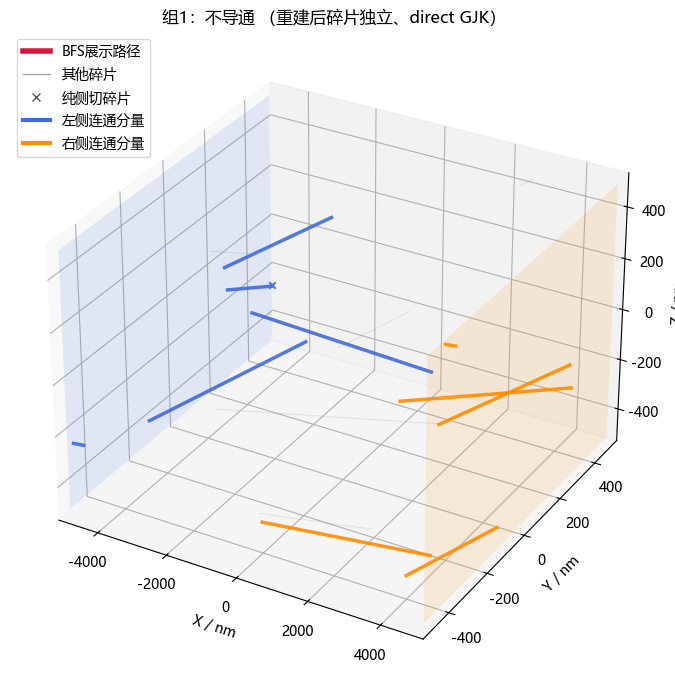

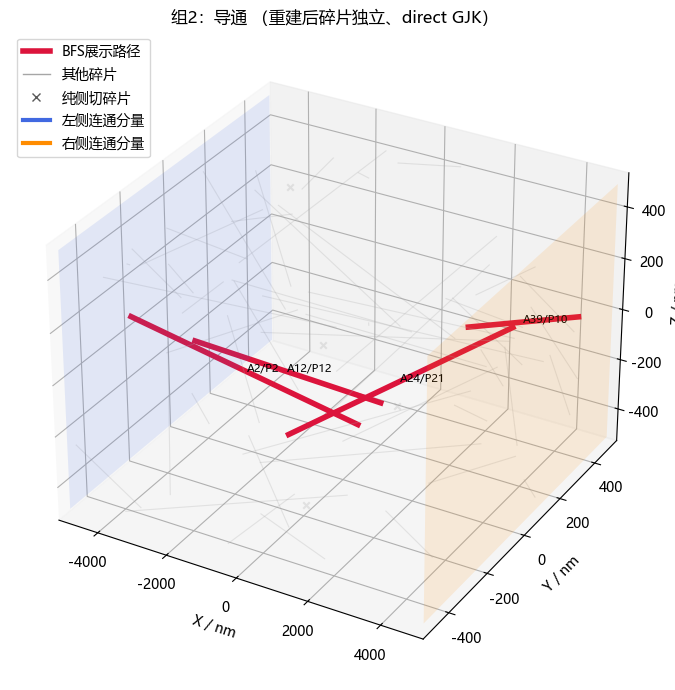

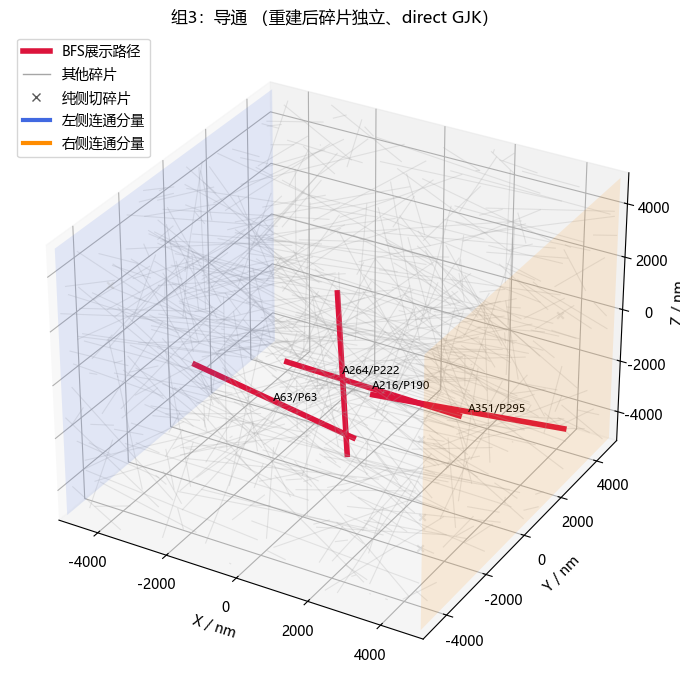

In [11]:
def reachable_nodes(adjacency: Sequence[set], source: int) -> set:
    reached = {source}
    queue = deque([source])
    while queue:
        node = queue.popleft()
        for neighbor in adjacency[node]:
            if neighbor not in reached:
                reached.add(neighbor)
                queue.append(neighbor)
    return reached


def plot_sheet(result: SheetResult):
    fig = plt.figure(figsize=(12, 7))
    ax = fig.add_subplot(111, projection="3d")
    path_fragments = (
        set() if result.path is None
        else set(result.path) - {result.left_node, result.right_node}
    )
    left_component = reachable_nodes(result.adjacency, result.left_node)
    right_component = reachable_nodes(result.adjacency, result.right_node)

    for index, fragment in enumerate(result.fragments):
        if index in path_fragments:
            color, width, alpha = "crimson", 4.0, 1.0
        elif result.path is None and index in left_component:
            color, width, alpha = "royalblue", 2.5, 0.9
        elif result.path is None and index in right_component:
            color, width, alpha = "darkorange", 2.5, 0.9
        else:
            color, width, alpha = "0.65", 0.8, 0.25

        segment = fragment.axis_visible_segment()
        if segment is None:
            point = fragment.cylinder.center + fragment.M @ fragment.feasible_y
            ax.scatter(*point, color=color, marker="x", s=22, alpha=alpha)
            label_point = point
        else:
            p, q = segment
            ax.plot(
                [p[0], q[0]], [p[1], q[1]], [p[2], q[2]],
                color=color, lw=width, alpha=alpha,
            )
            label_point = 0.5 * (p + q)
        if index in path_fragments:
            ax.text(*label_point, fragment.display_label, fontsize=8)

    half = result.reconstruction.half_extents
    y_values = np.array([-half[1], half[1]])
    z_values = np.array([-half[2], half[2]])
    Y, Z = np.meshgrid(y_values, z_values)
    for x, color in [(-half[0], "royalblue"), (half[0], "darkorange")]:
        X = np.full_like(Y, x, dtype=float)
        ax.plot_surface(X, Y, Z, color=color, alpha=0.12, shade=False)

    padding = np.maximum(30.0, 0.03 * half)
    ax.set_xlim(-half[0] - padding[0], half[0] + padding[0])
    ax.set_ylim(-half[1] - padding[1], half[1] + padding[1])
    ax.set_zlim(-half[2] - padding[2], half[2] + padding[2])
    ax.set_xlabel("X / nm")
    ax.set_ylabel("Y / nm")
    ax.set_zlabel("Z / nm")
    ax.set_title(
        f"{result.sheet_name}：{'导通' if result.conductive else '不导通'} "
        "（重建后碎片独立、direct GJK）"
    )
    ax.legend(handles=[
        Line2D([0], [0], color="crimson", lw=4, label="BFS展示路径"),
        Line2D([0], [0], color="0.65", lw=1, label="其他碎片"),
        Line2D([0], [0], marker="x", color="0.35", lw=0, label="纯侧切碎片"),
        Line2D([0], [0], color="royalblue", lw=3, label="左侧连通分量"),
        Line2D([0], [0], color="darkorange", lw=3, label="右侧连通分量"),
    ], loc="upper left")
    plt.tight_layout()
    if IN_NOTEBOOK:
        plt.show()
    else:
        plt.close(fig)


for result in results.values():
    plot_sheet(result)

## 10. 第一问结论与模型边界

在附件反推边界下，父圆柱数为 7、28、354，重裁剪后独立碎片数为 16、57、594。
附件恰好列出了其中轴长不小于 500 nm 的 12、49、535 个碎片；本模型还恢复了附件
省略的短轴碎片和纯侧切碎片。

最终判定为

\[
\boxed{\text{组1不导通，组2导通，组3导通}}.
\]

组2的一条路径对应附件数据行 `2→12→24→39`，组3对应
`63→264→216→351`。组1的歧义父圆柱在可行 alpha 区间左端、中点和右端均重新求解，
结论仍为不导通；组3的证据路径不包含其歧义父圆柱，因此对整个 alpha 区间稳定。

注意：`parent_id` 只追踪共同来源。最终没有 `periodic_images`，也没有任何“同源自动
union”。左右边界上的两个同源碎片只有在搬运后的真实几何距离不超过 1.8 nm 时，才会
由 direct GJK 正常建立边。